# ROL 1 | Analista de Incertidumbre e Información

**Proyecto Retador: Patrones Invisibles - UrbanMove**  
Este cuaderno analiza la demanda de recogidas y los patrones de movilidad a partir de `processed.csv`, generado en el ROL 4. La partición es cronológica: el 80% inicial se usa para estimar parámetros y perfiles; el 20% final queda reservado como validación.

**Fuente:** `../data/processed.csv`, con `pickup_datetime`, coordenadas y `trip_duration` en minutos. El cuaderno no crea datos sustitutos. Si el archivo o las columnas esperadas no están disponibles, se detiene con un error explícito.

**Convenciones:** las métricas discretas usan bits; la entropía diferencial usa nats y depende de las unidades. Laplace aditivo se compara con frecuencias sin suavizar. La duración y el destino son resultados posteriores al despacho: se analizan como diagnóstico retrospectivo, pero no determinan las probabilidades operativas de recogida.

> La asociación entre hora y destino es descriptiva y retrospectiva; el destino no está disponible al asignar un conductor.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from IPython.display import display, Markdown

SEED = 42
TRAIN_FRACTION = 0.80
GRID_SIZE = 8
LAPLACE_ALPHA = 1.0
NYC_BOUNDS = {"lon_min": -74.30, "lon_max": -73.60, "lat_min": 40.40, "lat_max": 41.00}

sns.set_theme(style="whitegrid", context="notebook", palette="crest")
plt.rcParams["figure.figsize"] = (11, 5)

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = next(
    (path for path in (NOTEBOOK_DIR, NOTEBOOK_DIR.parent) if (path / "data" / "processed.csv").exists()),
    NOTEBOOK_DIR,
)
DATA_CANDIDATES = [PROJECT_DIR / "data" / "processed.csv"]
DATA_PATH = DATA_CANDIDATES[0]
OUTPUT_DIR = PROJECT_DIR / "output" / "role_1"
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REQUIRED_COLUMNS = {
    "pickup_datetime", "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude", "trip_duration"
}
print(f"Directorio del proyecto: {PROJECT_DIR}")
print(f"CSV de entrada: {DATA_PATH}")
print(f"Directorio de resultados: {OUTPUT_DIR}")
print(f"Parámetros: grid={GRID_SIZE}x{GRID_SIZE}, alpha={LAPLACE_ALPHA}, train={TRAIN_FRACTION:.0%} cronológico")

Directorio del proyecto: C:\Users\L0s3r\OneDrive\Documentos\GitHub\NYC-Taxi-Unsupervised-Learning
CSV de entrada: C:\Users\L0s3r\OneDrive\Documentos\GitHub\NYC-Taxi-Unsupervised-Learning\data\processed.csv
Directorio de resultados: C:\Users\L0s3r\OneDrive\Documentos\GitHub\NYC-Taxi-Unsupervised-Learning\output\role_1
Parámetros: grid=8x8, alpha=1.0, train=80% cronológico


# **1. Lectura y Preparación de la Muestra**

## **1.1 Lectura de processed.csv y partición temporal**

Se conserva el 20% cronológico final como validación; las estimaciones de demanda usan solo entrenamiento. `processed.csv` expresa `trip_duration` en minutos: valores menores o iguales a cero y superiores a 360 minutos (6 horas) se etiquetan como anomalía, sin filtrar las probabilidades de recogida. Las recogidas fuera de NYC se excluyen de priors operativas; destinos inválidos se excluyen solo de análisis retrospectivos.

In [2]:
DATA_CANDIDATES = [NOTEBOOK_DIR.parent / "data" / "processed.csv", NOTEBOOK_DIR / "data" / "processed.csv"]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el archivo esperado: {DATA_PATH}")

raw_df = pd.read_csv(DATA_PATH, usecols=lambda column: column in REQUIRED_COLUMNS)
missing_columns = REQUIRED_COLUMNS.difference(raw_df.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas en {DATA_PATH.name}: {sorted(missing_columns)}")

# pickup_datetime de processed.csv conserva la hora local original de NYC.
raw_df["pickup_datetime"] = pd.to_datetime(raw_df["pickup_datetime"], errors="coerce")
raw_df["pickup_date"] = raw_df["pickup_datetime"].dt.date
n_invalid_datetime = int(raw_df["pickup_datetime"].isna().sum())
time_valid = raw_df.loc[raw_df["pickup_datetime"].notna()].copy()
time_valid = time_valid.sort_values("pickup_datetime", kind="stable").reset_index(drop=True)
if len(time_valid) < 100:
    raise ValueError("Se requieren al menos 100 viajes con fecha de recogida válida.")

cut_index = min(max(int(np.floor(len(time_valid) * TRAIN_FRACTION)) - 1, 0), len(time_valid) - 1)
train_cutoff = time_valid.loc[cut_index, "pickup_datetime"]
train_raw = time_valid.loc[time_valid["pickup_datetime"] <= train_cutoff].copy()
validation_raw = time_valid.loc[time_valid["pickup_datetime"] > train_cutoff].copy()

time_valid["pickup_spatial_anomaly"] = ~(
    time_valid["pickup_longitude"].between(NYC_BOUNDS["lon_min"], NYC_BOUNDS["lon_max"])
    & time_valid["pickup_latitude"].between(NYC_BOUNDS["lat_min"], NYC_BOUNDS["lat_max"])
)
time_valid["dropoff_spatial_anomaly"] = ~(
    time_valid["dropoff_longitude"].between(NYC_BOUNDS["lon_min"], NYC_BOUNDS["lon_max"])
    & time_valid["dropoff_latitude"].between(NYC_BOUNDS["lat_min"], NYC_BOUNDS["lat_max"])
)
time_valid["spatial_anomaly"] = time_valid["pickup_spatial_anomaly"] | time_valid["dropoff_spatial_anomaly"]
time_valid["duration_anomaly"] = ~time_valid["trip_duration"].between(1, 360)
time_valid["any_anomaly"] = time_valid["spatial_anomaly"] | time_valid["duration_anomaly"]

train_raw = time_valid.loc[time_valid.index.isin(train_raw.index)].copy()
validation_raw = time_valid.loc[time_valid.index.isin(validation_raw.index)].copy()
train_clean = train_raw.loc[~train_raw["pickup_spatial_anomaly"]].copy()
validation_clean = validation_raw.loc[~validation_raw["pickup_spatial_anomaly"]].copy()
if train_clean.empty:
    raise ValueError("El bloque de entrenamiento no contiene recogidas dentro del dominio NYC.")

quality_summary = pd.DataFrame({
    "Cohorte": ["processed.csv", "Fecha válida", "Entrenamiento temporal", "Validación temporal", "Entrenamiento con recogida válida"],
    "Viajes": [len(raw_df), len(time_valid), len(train_raw), len(validation_raw), len(train_clean)],
    "Porcentaje del CSV": [100.0, 100 * len(time_valid) / len(raw_df), 100 * len(train_raw) / len(raw_df),
                            100 * len(validation_raw) / len(raw_df), 100 * len(train_clean) / len(raw_df)],
})
print(f"Fuente: {DATA_PATH}")
print(f"Fechas inválidas excluidas: {n_invalid_datetime:,}")
print(f"Corte temporal de entrenamiento: {train_cutoff}")
print(f"Recogidas fuera de NYC en entrenamiento: {int(train_raw['pickup_spatial_anomaly'].sum()):,}")
print(f"Destinos fuera de NYC en entrenamiento: {int(train_raw['dropoff_spatial_anomaly'].sum()):,} (solo análisis retrospectivo)")
print(f"Duraciones fuera de 1-360 minutos: {int(train_raw['duration_anomaly'].sum()):,} (diagnóstico; no filtra demanda)")
display(quality_summary.style.format({"Viajes": "{:,.0f}", "Porcentaje del CSV": "{:.2f}%"}))

Fuente: C:\Users\L0s3r\OneDrive\Documentos\GitHub\NYC-Taxi-Unsupervised-Learning\data\processed.csv
Fechas inválidas excluidas: 0
Corte temporal de entrenamiento: 2016-05-23 17:39:00
Recogidas fuera de NYC en entrenamiento: 0
Destinos fuera de NYC en entrenamiento: 5 (solo análisis retrospectivo)
Duraciones fuera de 1-360 minutos: 105 (diagnóstico; no filtra demanda)


,Cohorte,Viajes,Porcentaje del CSV
0,processed.csv,"40,000",100.00%
1,Fecha válida,"40,000",100.00%
2,Entrenamiento temporal,"32,000",80.00%
3,Validación temporal,"8,000",20.00%
4,Entrenamiento con recogida válida,"32,000",80.00%


## **1.2 Control de calidad espacial por extremo**

Los límites geográficos son una regla fija para el área de NYC; el ajuste estadístico del grid se hará después y solo con recogidas válidas del entrenamiento.

In [3]:
# Control reproducible por extremo; el destino no determina si la recogida entra en demanda.
def inside_nyc(longitude, latitude):
    return (
        longitude.between(NYC_BOUNDS["lon_min"], NYC_BOUNDS["lon_max"])
        & latitude.between(NYC_BOUNDS["lat_min"], NYC_BOUNDS["lat_max"])
    )


train_raw["pickup_spatial_anomaly"] = ~inside_nyc(train_raw["pickup_longitude"], train_raw["pickup_latitude"])
train_raw["dropoff_spatial_anomaly"] = ~inside_nyc(train_raw["dropoff_longitude"], train_raw["dropoff_latitude"])
train_raw["spatial_anomaly"] = train_raw["pickup_spatial_anomaly"] | train_raw["dropoff_spatial_anomaly"]
train_raw["any_anomaly"] = train_raw["spatial_anomaly"] | train_raw["duration_anomaly"]
train_clean = train_raw.loc[~train_raw["pickup_spatial_anomaly"]].copy()
validation_clean = validation_raw.loc[
    inside_nyc(validation_raw["pickup_longitude"], validation_raw["pickup_latitude"])
].copy()
quality_summary.loc[quality_summary["Cohorte"] == "Entrenamiento con recogida válida", "Viajes"] = len(train_clean)
quality_summary.loc[quality_summary["Cohorte"] == "Entrenamiento con recogida válida", "Porcentaje del CSV"] = 100 * len(train_clean) / len(raw_df)
print(f"Recogidas fuera de NYC: {int(train_raw['pickup_spatial_anomaly'].sum()):,}")
print(f"Destinos fuera de NYC (retrospectivo): {int(train_raw['dropoff_spatial_anomaly'].sum()):,}")
display(quality_summary.style.format({"Viajes": "{:,.0f}", "Porcentaje del CSV": "{:.2f}%"}))

Recogidas fuera de NYC: 0
Destinos fuera de NYC (retrospectivo): 5


,Cohorte,Viajes,Porcentaje del CSV
0,processed.csv,"40,000",100.00%
1,Fecha válida,"40,000",100.00%
2,Entrenamiento temporal,"32,000",80.00%
3,Validación temporal,"8,000",20.00%
4,Entrenamiento con recogida válida,"32,000",80.00%


# **2. Construcción de Distribuciones de Probabilidad**

## **2.1 Discretización geográfica aprendida en entrenamiento**

El dominio de NYC es un control fijo. Los límites numéricos del grid se ajustan solo con recogidas válidas del entrenamiento y se reutilizan sin reajuste para cualquier subconjunto posterior.

In [4]:
def fit_grid(frame, grid_size=GRID_SIZE):
    """Ajusta los límites del grid usando recogidas válidas del bloque de entrenamiento."""
    bounds = {
        "lon_min": float(frame["pickup_longitude"].min()),
        "lon_max": float(frame["pickup_longitude"].max()),
        "lat_min": float(frame["pickup_latitude"].min()),
        "lat_max": float(frame["pickup_latitude"].max()),
    }
    if bounds["lon_min"] == bounds["lon_max"] or bounds["lat_min"] == bounds["lat_max"]:
        raise ValueError("No se puede ajustar el grid: coordenadas de entrenamiento sin variación.")
    return {**bounds, "grid_size": int(grid_size)}


def transform_grid(frame, longitude, latitude, grid):
    """Asigna zonas con límites aprendidos en train; no reajusta parámetros con frame."""
    lon = frame[longitude].to_numpy(dtype=float)
    lat = frame[latitude].to_numpy(dtype=float)
    lon_fraction = np.clip((lon - grid["lon_min"]) / (grid["lon_max"] - grid["lon_min"]), 0, 1)
    lat_fraction = np.clip((lat - grid["lat_min"]) / (grid["lat_max"] - grid["lat_min"]), 0, 1)
    col = np.minimum((lon_fraction * grid["grid_size"]).astype(int), grid["grid_size"] - 1)
    row = np.minimum((lat_fraction * grid["grid_size"]).astype(int), grid["grid_size"] - 1)
    labels = np.array([f"R{r:02d}C{c:02d}" for r, c in zip(row, col)], dtype=object)
    inside_nyc = (
        (lon >= NYC_BOUNDS["lon_min"]) & (lon <= NYC_BOUNDS["lon_max"])
        & (lat >= NYC_BOUNDS["lat_min"]) & (lat <= NYC_BOUNDS["lat_max"])
    )
    labels[~inside_nyc] = "FUERA_NYC"
    return labels


def add_demand_features(frame, grid):
    """Construye hora, tipo de día y zonas; cada extremo se representa por separado."""
    result = frame.copy()
    result["hour"] = result["pickup_datetime"].dt.hour
    result["day_type"] = np.where(result["pickup_datetime"].dt.dayofweek >= 5, "Fin de semana", "Laboral")
    result["origin_zone"] = transform_grid(result, "pickup_longitude", "pickup_latitude", grid)
    result["destination_zone"] = transform_grid(result, "dropoff_longitude", "dropoff_latitude", grid)
    return result


grid_parameters = fit_grid(train_clean)
train_raw_features = add_demand_features(train_raw, grid_parameters)
train_clean_features = add_demand_features(train_clean, grid_parameters)
validation_features = add_demand_features(validation_clean, grid_parameters)

print("Límites del grid aprendidos solo con recogidas válidas de entrenamiento:")
display(pd.Series(grid_parameters, name="Valor").to_frame())
print("Muestra de las variables discretas de demanda:")
display(train_clean_features[["pickup_datetime", "hour", "day_type", "origin_zone", "destination_zone"]].head())

Límites del grid aprendidos solo con recogidas válidas de entrenamiento:


,Valor
lon_min,-74.184074
lon_max,-73.636971
lat_min,40.413231
lat_max,40.880497
grid_size,8.000000


Muestra de las variables discretas de demanda:


,pickup_datetime,hour,day_type,origin_zone,destination_zone
0,2016-01-01 00:01:01,0,Laboral,R06C03,R06C03
1,2016-01-01 00:07:22,0,Laboral,R06C03,R06C03
2,2016-01-01 00:28:41,0,Laboral,R06C02,R06C03
3,2016-01-01 00:30:07,0,Laboral,R05C03,R05C03
4,2016-01-01 00:31:54,0,Laboral,R05C02,R06C03


## **2.2 Estimación de distribuciones discretas P(X)**

Se construyen frecuencias de recogida por celda, hora local y tipo de día. El soporte espacial de 64 celdas permanece fijo para que las probabilidades sean comparables.

In [5]:
zone_support = [f"R{row:02d}C{col:02d}" for row in range(GRID_SIZE) for col in range(GRID_SIZE)]
zone_support_with_noise = zone_support + ["FUERA_NYC"]
HOURS = list(range(24))
DAY_TYPES = ["Laboral", "Fin de semana"]


def smoothed_probability(counts, support, alpha=LAPLACE_ALPHA):
    """Probabilidad de Laplace sobre soporte fijo; alpha=0 devuelve frecuencia empírica."""
    vector = pd.Series(counts, dtype=float).reindex(support, fill_value=0.0).to_numpy()
    if alpha < 0:
        raise ValueError("alpha debe ser >= 0")
    denominator = vector.sum() + alpha * len(support)
    if denominator <= 0:
        raise ValueError("No hay conteos ni suavizado para estimar la distribución.")
    return (vector + alpha) / denominator


def entropy_bits(probabilities):
    """Entropía de Shannon discreta en bits."""
    p = np.asarray(probabilities, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


def conditional_entropy_bits(frame, given, outcome, outcome_support, alpha=0.0):
    """H(outcome|given), promediada con frecuencias empíricas de given."""
    total = len(frame)
    result = 0.0
    for _, group in frame.groupby(given, observed=True):
        weight = len(group) / total
        counts = group[outcome].value_counts()
        result += weight * entropy_bits(smoothed_probability(counts, outcome_support, alpha))
    return float(result)


origin_counts = train_clean_features["origin_zone"].value_counts()
hour_counts = train_clean_features["hour"].value_counts()
day_type_counts = train_clean_features["day_type"].value_counts()
P_zone = smoothed_probability(origin_counts, zone_support, alpha=0)
P_hour = smoothed_probability(hour_counts, HOURS, alpha=0)
P_day_type = smoothed_probability(day_type_counts, DAY_TYPES, alpha=0)

probability_tables = {
    "Zona de recogida": pd.DataFrame({"viajes": origin_counts.reindex(zone_support, fill_value=0)}).assign(
        probabilidad=lambda table: smoothed_probability(table["viajes"], zone_support, alpha=0)
    ).sort_values("viajes", ascending=False),
    "Hora de recogida": pd.DataFrame({"viajes": hour_counts.reindex(HOURS, fill_value=0)}).assign(
        probabilidad=lambda table: smoothed_probability(table["viajes"], HOURS, alpha=0)
    ),
    "Tipo de día": pd.DataFrame({"viajes": day_type_counts.reindex(DAY_TYPES, fill_value=0)}).assign(
        probabilidad=lambda table: smoothed_probability(table["viajes"], DAY_TYPES, alpha=0)
    ),
}
for distribution_name, probability_table in probability_tables.items():
    print(f"P(X): {distribution_name}")
    display(probability_table.style.format({"viajes": "{:,.0f}", "probabilidad": "{:.5f}"}))

P(X): Zona de recogida


,viajes,probabilidad
origin_zone,,
R05C02,"15,096",0.47175
R06C03,"7,102",0.22194
R05C03,"5,145",0.16078
R06C02,"2,375",0.07422
R06C04,802,0.02506
R03C05,523,0.01634
R04C02,462,0.01444
R04C03,148,0.00462
R04C05,130,0.00406


P(X): Hora de recogida


,viajes,probabilidad
hour,,
0,"1,180",0.03687
1,854,0.02669
2,608,0.01900
3,459,0.01434
4,358,0.01119
5,361,0.01128
6,728,0.02275
7,"1,196",0.03737
8,"1,489",0.04653


P(X): Tipo de día


,viajes,probabilidad
day_type,,
Laboral,"22,557",0.70491
Fin de semana,"9,443",0.29509


# **3. Métricas de Incertidumbre e Información**

## **3.1 Entropía de Shannon y entropía condicional**

Se cuantifica la incertidumbre espacial total y la incertidumbre restante al conocer la hora; también se estima el nivel de demanda diaria condicionado al tipo de día.

## **3.2 Información mutua hora-zona**

Se mide la información aportada por la hora sobre zonas de recogida y, como análisis retrospectivo separado, de destino.

## **3.3 Divergencia KL y entropía cruzada**

Se comparan los perfiles laboral y fin de semana en ambas direcciones sobre soporte común, con y sin suavizado de Laplace.

In [6]:
def joint_probability(frame, outcome, outcome_support, condition="hour", condition_support=HOURS):
    counts = pd.crosstab(frame[condition], frame[outcome]).reindex(
        index=condition_support, columns=outcome_support, fill_value=0
    ).to_numpy(dtype=float)
    return counts / counts.sum()


def mutual_information_bits(joint):
    """I(A;B) en bits, calculada desde la tabla conjunta empírica."""
    joint = np.asarray(joint, dtype=float)
    marginal_a = joint.sum(axis=1, keepdims=True)
    marginal_b = joint.sum(axis=0, keepdims=True)
    expected = marginal_a @ marginal_b
    valid = joint > 0
    return float(np.sum(joint[valid] * np.log2(joint[valid] / expected[valid])))


def pointwise_information_bits(joint):
    """Aporte firmado p(a,b) log2[p(a,b)/(p(a)p(b))] por celda."""
    joint = np.asarray(joint, dtype=float)
    expected = joint.sum(axis=1, keepdims=True) @ joint.sum(axis=0, keepdims=True)
    contribution = np.zeros_like(joint)
    valid = joint > 0
    contribution[valid] = joint[valid] * np.log2(joint[valid] / expected[valid])
    return contribution


def kl_bits(p, q):
    """D_KL(P||Q) en bits; devuelve infinito si Q asigna cero a masa positiva de P."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    if np.any((p > 0) & (q == 0)):
        return float("inf")
    valid = p > 0
    return float(np.sum(p[valid] * np.log2(p[valid] / q[valid])))


def cross_entropy_bits(p, q):
    """H(P,Q) en bits, con infinito ante masa de P no cubierta por Q."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    if np.any((p > 0) & (q == 0)):
        return float("inf")
    valid = p > 0
    return float(-np.sum(p[valid] * np.log2(q[valid])))


# H(Zona | Hora) y su perfil horario: localización residual tras conocer la hora.
H_zone_given_hour = conditional_entropy_bits(
    train_clean_features, "hour", "origin_zone", zone_support, alpha=0
)
entropy_by_hour = pd.Series({
    hour: entropy_bits(smoothed_probability(group["origin_zone"].value_counts(), zone_support, alpha=0))
    for hour, group in train_clean_features.groupby("hour", observed=True)
}).reindex(HOURS)

hour_bands = {
    "Pico mañana (07-09)": [7, 8, 9],
    "Pico noche (16-19)": [16, 17, 18, 19],
    "Valle (00-05)": [0, 1, 2, 3, 4, 5],
}
H_by_band = {}
for band_name, hours in hour_bands.items():
    band_frame = train_clean_features.loc[train_clean_features["hour"].isin(hours)]
    H_by_band[band_name] = entropy_bits(
        smoothed_probability(band_frame["origin_zone"].value_counts(), zone_support, alpha=0)
    )

# Volumen diario de recogidas, discretizado con cuantiles aprendidos solo en entrenamiento limpio.
daily_demand = train_clean_features.groupby("pickup_date", observed=True).size().rename("pickups").to_frame()
daily_dates = pd.to_datetime(daily_demand.index)
daily_demand["day_type"] = np.where(daily_dates.dayofweek >= 5, "Fin de semana", "Laboral")
demand_q1, demand_q2 = daily_demand["pickups"].quantile([1 / 3, 2 / 3]).to_numpy()
daily_demand["demand_level"] = np.select(
    [daily_demand["pickups"] <= demand_q1, daily_demand["pickups"] <= demand_q2],
    ["Baja", "Media"], default="Alta"
)
demand_levels = ["Baja", "Media", "Alta"]
H_demand_given_day_type = conditional_entropy_bits(
    daily_demand.reset_index(), "day_type", "demand_level", demand_levels, alpha=0
)
demand_by_day_type = pd.crosstab(daily_demand["day_type"], daily_demand["demand_level"]).reindex(
    index=DAY_TYPES, columns=demand_levels, fill_value=0
)

# Información mutua de la hora con zonas de origen y destino; destino es análisis retrospectivo.
J_origin = joint_probability(train_clean_features, "origin_zone", zone_support)
J_destination = joint_probability(train_clean_features, "destination_zone", zone_support)
MI_hour_origin = mutual_information_bits(J_origin)
MI_hour_destination = mutual_information_bits(J_destination)

# KL, entropía cruzada y entropía por tipo de día sobre el mismo soporte fijo del grid.
weekday_frame = train_clean_features.loc[train_clean_features["day_type"] == "Laboral"]
weekend_frame = train_clean_features.loc[train_clean_features["day_type"] == "Fin de semana"]
weekday_counts = weekday_frame["origin_zone"].value_counts()
weekend_counts = weekend_frame["origin_zone"].value_counts()
P_weekday_raw = smoothed_probability(weekday_counts, zone_support, alpha=0)
Q_weekend_raw = smoothed_probability(weekend_counts, zone_support, alpha=0)
P_weekday = smoothed_probability(weekday_counts, zone_support, alpha=LAPLACE_ALPHA)
Q_weekend = smoothed_probability(weekend_counts, zone_support, alpha=LAPLACE_ALPHA)

smoothing_rows = []
for alpha in [0.0, LAPLACE_ALPHA]:
    p = smoothed_probability(weekday_counts, zone_support, alpha=alpha)
    q = smoothed_probability(weekend_counts, zone_support, alpha=alpha)
    smoothing_rows.extend([
        {"alpha": alpha, "Métrica": "H(Laboral)", "Valor": entropy_bits(p), "Unidad": "bits/viaje"},
        {"alpha": alpha, "Métrica": "H(Fin de semana)", "Valor": entropy_bits(q), "Unidad": "bits/viaje"},
        {"alpha": alpha, "Métrica": "D_KL(Laboral||Fin de semana)", "Valor": kl_bits(p, q), "Unidad": "bits/viaje"},
        {"alpha": alpha, "Métrica": "D_KL(Fin de semana||Laboral)", "Valor": kl_bits(q, p), "Unidad": "bits/viaje"},
        {"alpha": alpha, "Métrica": "H(Laboral, Fin de semana)", "Valor": cross_entropy_bits(p, q), "Unidad": "bits/viaje"},
        {"alpha": alpha, "Métrica": "H(Fin de semana, Laboral)", "Valor": cross_entropy_bits(q, p), "Unidad": "bits/viaje"},
    ])
smoothing_comparison = pd.DataFrame(smoothing_rows)

kl_comparison = pd.DataFrame([
    {"Dirección": "Laboral || Fin de semana", "Pérdida informativa": kl_bits(P_weekday, Q_weekend), "Unidad": "bits/viaje"},
    {"Dirección": "Fin de semana || Laboral", "Pérdida informativa": kl_bits(Q_weekend, P_weekday), "Unidad": "bits/viaje"},
])
cross_entropy_comparison = pd.DataFrame([
    {"Real P / estrategia Q": "Laboral / fin de semana", "Costo": cross_entropy_bits(P_weekday, Q_weekend), "Unidad": "bits/viaje"},
    {"Real P / estrategia Q": "Fin de semana / laboral", "Costo": cross_entropy_bits(Q_weekend, P_weekday), "Unidad": "bits/viaje"},
])

print(f"H(Zona) global: {entropy_bits(P_zone):.4f} bits/viaje")
print(f"H(Zona | Hora): {H_zone_given_hour:.4f} bits/viaje")
print(f"H(Demanda diaria | Tipo de día): {H_demand_given_day_type:.4f} bits/día")
print(f"I(Hora; Zona origen): {MI_hour_origin:.4f} bits/viaje")
print(f"I(Hora; Zona destino): {MI_hour_destination:.4f} bits/viaje (descriptiva, no disponible al despacho)")
print("Entropía espacial por franja:")
display(pd.Series(H_by_band, name="Entropía espacial (bits/viaje)").to_frame())
print("Divergencias dirigidas con Laplace:")
display(kl_comparison.style.format({"Pérdida informativa": "{:.5f}"}))
print("Entropía cruzada: costo informativo de la estrategia equivocada:")
display(cross_entropy_comparison.style.format({"Costo": "{:.5f}"}))
print("Efecto del suavizado aditivo en probabilidades espaciales:")
display(smoothing_comparison.style.format({"Valor": "{:.5f}"}))
print("Distribución de niveles de demanda diaria por tipo de día:")
display(demand_by_day_type)

H(Zona) global: 2.1462 bits/viaje
H(Zona | Hora): 2.1049 bits/viaje
H(Demanda diaria | Tipo de día): 1.5584 bits/día
I(Hora; Zona origen): 0.0413 bits/viaje
I(Hora; Zona destino): 0.0570 bits/viaje (descriptiva, no disponible al despacho)
Entropía espacial por franja:


,Entropía espacial (bits/viaje)
Pico mañana (07-09),2.164520
Pico noche (16-19),2.164483
Valle (00-05),1.880047


Divergencias dirigidas con Laplace:


,Dirección,Pérdida informativa,Unidad
0,Laboral || Fin de semana,0.01770,bits/viaje
1,Fin de semana || Laboral,0.01835,bits/viaje


Entropía cruzada: costo informativo de la estrategia equivocada:


,Real P / estrategia Q,Costo,Unidad
0,Laboral / fin de semana,2.21959,bits/viaje
1,Fin de semana / laboral,2.16892,bits/viaje


Efecto del suavizado aditivo en probabilidades espaciales:


,alpha,Métrica,Valor,Unidad
0,0.000000,H(Laboral),2.16942,bits/viaje
1,0.000000,H(Fin de semana),2.07897,bits/viaje
2,0.000000,D_KL(Laboral||Fin de semana),inf,bits/viaje
3,0.000000,D_KL(Fin de semana||Laboral),inf,bits/viaje
4,0.000000,"H(Laboral, Fin de semana)",inf,bits/viaje
5,0.000000,"H(Fin de semana, Laboral)",inf,bits/viaje
6,1.000000,H(Laboral),2.20190,bits/viaje
7,1.000000,H(Fin de semana),2.15056,bits/viaje
8,1.000000,D_KL(Laboral||Fin de semana),0.01770,bits/viaje
9,1.000000,D_KL(Fin de semana||Laboral),0.01835,bits/viaje


Distribución de niveles de demanda diaria por tipo de día:


demand_level,Baja,Media,Alta
day_type,,,
Laboral,37,37,28
Fin de semana,11,11,20


In [7]:
# La asociación con destino se estima solo para destinos válidos y sigue siendo retrospectiva.
valid_destination_frame = train_clean_features.loc[~train_clean_features["dropoff_spatial_anomaly"]]
J_destination = joint_probability(valid_destination_frame, "destination_zone", zone_support)
MI_hour_destination = mutual_information_bits(J_destination)
print(f"Viajes válidos para I(Hora; Zona destino): {len(valid_destination_frame):,}")
print(f"I(Hora; Zona destino): {MI_hour_destination:.5f} bits/viaje (retrospectiva)")

Viajes válidos para I(Hora; Zona destino): 31,995
I(Hora; Zona destino): 0.05698 bits/viaje (retrospectiva)


# **4. Comparativas de Ruido, Escalado y Estabilidad Numérica**

## **4.1 Efecto del ruido en las métricas de información**

Se contrastan las distribuciones espaciales observadas frente a las cohortes sin anomalías de recogida y, por separado, de destino.

## **4.2 Desigualdad de Jensen y Log-Sum-Exp**

Se valida Jensen sobre las probabilidades empíricas de recogida y se prueba la API estable de suma logarítmica para el ROL 3.

## **4.3 Efecto del escalado en entropía diferencial**

Los escaladores se ajustan solo en entrenamiento; la entropía diferencial se contrasta en minutos, MinMax y Standard. Validación recibe únicamente `transform`.

In [8]:
# Contraste de ruido: recogidas y destinos se evalúan con banderas independientes.
valid_destination_frame = train_clean_features.loc[~train_clean_features["dropoff_spatial_anomaly"]]
J_origin_raw = joint_probability(train_raw_features, "origin_zone", zone_support_with_noise)
J_origin_clean = joint_probability(train_clean_features, "origin_zone", zone_support_with_noise)
J_destination_raw = joint_probability(train_raw_features, "destination_zone", zone_support_with_noise)
J_destination_clean = joint_probability(valid_destination_frame, "destination_zone", zone_support_with_noise)
noise_comparison = pd.DataFrame([
    {
        "Cohorte": "Con anomalías",
        "H(Zona origen)": entropy_bits(smoothed_probability(train_raw_features["origin_zone"].value_counts(), zone_support_with_noise, alpha=0)),
        "H(Zona destino)": entropy_bits(smoothed_probability(train_raw_features["destination_zone"].value_counts(), zone_support_with_noise, alpha=0)),
        "H(Hora)": entropy_bits(smoothed_probability(train_raw_features["hour"].value_counts(), HOURS, alpha=0)),
        "I(Hora; Zona origen)": mutual_information_bits(J_origin_raw),
        "I(Hora; Zona destino)": mutual_information_bits(J_destination_raw),
        "Recogida fuera NYC (%)": 100 * train_raw["pickup_spatial_anomaly"].mean(),
        "Destino fuera NYC (%)": 100 * train_raw["dropoff_spatial_anomaly"].mean(),
    },
    {
        "Cohorte": "Sin anomalías espaciales",
        "H(Zona origen)": entropy_bits(smoothed_probability(train_clean_features["origin_zone"].value_counts(), zone_support_with_noise, alpha=0)),
        "H(Zona destino)": entropy_bits(smoothed_probability(valid_destination_frame["destination_zone"].value_counts(), zone_support_with_noise, alpha=0)),
        "H(Hora)": entropy_bits(smoothed_probability(train_clean_features["hour"].value_counts(), HOURS, alpha=0)),
        "I(Hora; Zona origen)": mutual_information_bits(J_origin_clean),
        "I(Hora; Zona destino)": mutual_information_bits(J_destination_clean),
        "Recogida fuera NYC (%)": 100 * train_clean_features["origin_zone"].eq("FUERA_NYC").mean(),
        "Destino fuera NYC (%)": 100 * valid_destination_frame["destination_zone"].eq("FUERA_NYC").mean(),
    },
])
print("Comparación de métricas con anomalías vs. sin anomalías espaciales:")
display(noise_comparison.style.format({
    "H(Zona origen)": "{:.5f}", "H(Zona destino)": "{:.5f}", "H(Hora)": "{:.5f}",
    "I(Hora; Zona origen)": "{:.5f}", "I(Hora; Zona destino)": "{:.5f}",
    "Recogida fuera NYC (%)": "{:.3f}%", "Destino fuera NYC (%)": "{:.3f}%",
}))

# Jensen para log2, aplicada a las probabilidades de zona de recogida X~P.
positive_zone_probabilities = P_zone[P_zone > 0]
jensen_left = float(np.sum(positive_zone_probabilities * np.log2(positive_zone_probabilities)))
jensen_right = float(np.log2(np.sum(positive_zone_probabilities ** 2)))
jensen_gap = jensen_right - jensen_left
assert jensen_left <= jensen_right + 1e-12, "La desigualdad de Jensen no se cumple numéricamente."
jensen_result = pd.DataFrame([{
    "E[log2 P(X)]": jensen_left,
    "log2 E[P(X)]": jensen_right,
    "Margen": jensen_gap,
    "Unidad": "bits",
}])
print("Jensen: E[log2 P(X)] <= log2 E[P(X)] sobre zonas de recogida:")
display(jensen_result.style.format({"E[log2 P(X)]": "{:.8f}", "log2 E[P(X)]": "{:.8f}", "Margen": "{:.8f}"}))

# API ROL 1 -> ROL 3: combinación estable de log-probabilidades.
def logsumexp_stable(log_values, axis=None, keepdims=False):
    """Calcula log(sum(exp(x))) evitando overflow y underflow numérico."""
    values = np.asarray(log_values, dtype=float)
    if values.size == 0:
        raise ValueError("logsumexp requiere al menos un valor.")
    maximum = np.max(values, axis=axis, keepdims=True)
    with np.errstate(invalid="ignore", divide="ignore", over="ignore", under="ignore"):
        shifted = np.where(np.isfinite(maximum), values - maximum, -np.inf)
        result = maximum + np.log(np.sum(np.exp(shifted), axis=axis, keepdims=True))
    result = np.where(np.isposinf(maximum), np.inf, result)
    result = np.where(np.isneginf(maximum), -np.inf, result)
    if not keepdims and axis is not None:
        result = np.squeeze(result, axis=axis)
    elif not keepdims and axis is None:
        result = np.squeeze(result)
    return result


def log_mixture_probability(log_component_probabilities, weights=None, axis=0):
    """Agrega probabilidades de componentes con pesos usando exclusivamente log-espacio."""
    log_probabilities = np.asarray(log_component_probabilities, dtype=float)
    if weights is None:
        log_weights = np.full(log_probabilities.shape[axis], -np.log(log_probabilities.shape[axis]))
    else:
        weights = np.asarray(weights, dtype=float)
        if np.any(weights < 0) or weights.sum() <= 0:
            raise ValueError("Los pesos deben ser no negativos y sumar un valor positivo.")
        weights = weights / weights.sum()
        with np.errstate(divide="ignore"):
            log_weights = np.log(weights)
    reshape = [1] * log_probabilities.ndim
    reshape[axis] = len(log_weights)
    return logsumexp_stable(log_probabilities + log_weights.reshape(reshape), axis=axis)


extreme_log_values = np.array([-1000.0, -1001.0, -999.0])
large_log_values = np.array([1000.0, 1001.0, 999.0])
with np.errstate(divide="ignore", over="ignore", under="ignore"):
    naive_underflow = np.log(np.exp(extreme_log_values).sum())
    naive_overflow = np.exp(large_log_values).sum()
stable_underflow = float(logsumexp_stable(extreme_log_values))
stable_overflow = float(logsumexp_stable(large_log_values))
example_zone_log_probabilities = np.log(np.array([0.2, 0.3, 0.5]))
mixture_log_probability = float(log_mixture_probability(example_zone_log_probabilities, weights=[0.2, 0.3, 0.5]))
logsumexp_checks = pd.DataFrame([
    {"Caso": "Log-suma directa bajo flujo", "Resultado": naive_underflow, "Estado": "-inf/erróneo"},
    {"Caso": "Log-suma estable bajo flujo", "Resultado": stable_underflow, "Estado": "finito"},
    {"Caso": "Suma exponencial directa sobre flujo", "Resultado": naive_overflow, "Estado": "inf/erróneo"},
    {"Caso": "Log-suma estable sobre flujo", "Resultado": stable_overflow, "Estado": "finito"},
    {"Caso": "Mezcla ponderada de probabilidades por zona", "Resultado": mixture_log_probability, "Estado": "log(1)=0 esperado"},
])
print("Pruebas de la API log-sum-exp para el ROL 3 (GMM/EM):")
display(logsumexp_checks.style.format({"Resultado": "{:.8g}"}))

Comparación de métricas con anomalías vs. sin anomalías espaciales:


,Cohorte,H(Zona origen),H(Zona destino),H(Hora),I(Hora; Zona origen),I(Hora; Zona destino),Recogida fuera NYC (%),Destino fuera NYC (%)
0,Con anomalías,2.14624,2.39837,4.46680,0.04134,0.05727,0.000%,0.016%
1,Sin anomalías espaciales,2.14624,2.39654,4.46680,0.04134,0.05698,0.000%,0.000%


Jensen: E[log2 P(X)] <= log2 E[P(X)] sobre zonas de recogida:


,E[log2 P(X)],log2 E[P(X)],Margen,Unidad
0,-2.14624491,-1.71634189,0.42990302,bits


Pruebas de la API log-sum-exp para el ROL 3 (GMM/EM):


,Caso,Resultado,Estado
0,Log-suma directa bajo flujo,-inf,-inf/erróneo
1,Log-suma estable bajo flujo,-998.59239,finito
2,Suma exponencial directa sobre flujo,inf,inf/erróneo
3,Log-suma estable sobre flujo,1001.4076,finito
4,Mezcla ponderada de probabilidades por zona,-0.96758403,log(1)=0 esperado


In [9]:
from scipy.stats import differential_entropy

# trip_duration está en minutos; se filtra solo para este análisis del resultado del viaje.
train_duration_clean = train_clean_features.loc[
    train_clean_features["trip_duration"].between(1, 360), "trip_duration"
].to_numpy(dtype=float)
if len(train_duration_clean) < 100:
    raise ValueError("Se requieren al menos 100 duraciones válidas en entrenamiento para comparar escalas.")
rng = np.random.default_rng(SEED)
density_sample_size = min(100_000, len(train_duration_clean))
density_sample = rng.choice(train_duration_clean, size=density_sample_size, replace=False).reshape(-1, 1)
minmax_scaler = MinMaxScaler().fit(density_sample)
standard_scaler = StandardScaler().fit(density_sample)
raw_duration_sample = density_sample.ravel()
minmax_duration = minmax_scaler.transform(density_sample).ravel()
standard_duration = standard_scaler.transform(density_sample).ravel()

h_duration_raw = float(differential_entropy(raw_duration_sample))
h_duration_minmax = float(differential_entropy(minmax_duration))
h_duration_standard = float(differential_entropy(standard_duration))
scaling_comparison = pd.DataFrame([
    {"Representación": "Original", "Escala": "minutos", "h diferencial observado": h_duration_raw,
     "h esperada por cambio afín": h_duration_raw, "Unidad": "nats (variable en minutos)"},
    {"Representación": "MinMax", "Escala": "[0, 1]", "h diferencial observado": h_duration_minmax,
     "h esperada por cambio afín": h_duration_raw + np.log(float(minmax_scaler.scale_[0])), "Unidad": "nats (variable adimensional)"},
    {"Representación": "Standard", "Escala": "media 0, varianza 1", "h diferencial observado": h_duration_standard,
     "h esperada por cambio afín": h_duration_raw + np.log(float(standard_scaler.scale_[0])), "Unidad": "nats (variable adimensional)"},
])
scaling_comparison["Diferencia observado-esperado"] = (
    scaling_comparison["h diferencial observado"] - scaling_comparison["h esperada por cambio afín"]
)

# Se transforman también los cortes cuantílicos; con los mismos cortes la entropía discreta es invariante.
quantile_edges = np.quantile(raw_duration_sample, np.linspace(0, 1, 11)[1:-1])
raw_duration_bins = np.digitize(raw_duration_sample, quantile_edges, right=True)
minmax_edges = minmax_scaler.transform(quantile_edges.reshape(-1, 1)).ravel()
standard_edges = standard_scaler.transform(quantile_edges.reshape(-1, 1)).ravel()
minmax_duration_bins = np.digitize(minmax_duration, minmax_edges, right=True)
standard_duration_bins = np.digitize(standard_duration, standard_edges, right=True)
discrete_scaling_comparison = pd.DataFrame([
    {"Representación": "Original", "H(10 bins)": entropy_bits(np.bincount(raw_duration_bins, minlength=10) / len(raw_duration_bins)), "Unidad": "bits/viaje"},
    {"Representación": "MinMax", "H(10 bins)": entropy_bits(np.bincount(minmax_duration_bins, minlength=10) / len(minmax_duration_bins)), "Unidad": "bits/viaje"},
    {"Representación": "Standard", "H(10 bins)": entropy_bits(np.bincount(standard_duration_bins, minlength=10) / len(standard_duration_bins)), "Unidad": "bits/viaje"},
])

# Validación recibe únicamente transform() con parámetros ya ajustados en entrenamiento.
validation_duration_scaled = standard_scaler.transform(
    validation_features["trip_duration"].to_numpy(dtype=float).reshape(-1, 1)
) if len(validation_features) else np.array([])
print(f"Muestra para densidad: {density_sample_size:,} duraciones de entrenamiento entre 1 y 360 minutos.")
print(f"Parámetros StandardScaler: media={standard_scaler.mean_[0]:.4f} min, escala={standard_scaler.scale_[0]:.4f} min")
print(f"Duraciones fuera de rango excluidas solo de este análisis: {len(train_clean_features) - len(train_duration_clean):,}")
print("La entropía diferencial cambia con la escala: h(aX+b)=h(X)+ln|a|, medida en nats.")
display(scaling_comparison.style.format({
    "h diferencial observado": "{:.5f}", "h esperada por cambio afín": "{:.5f}",
    "Diferencia observado-esperado": "{:.5f}"
}))
print("Entropía discreta con cortes transformados coherentemente:")
display(discrete_scaling_comparison.style.format({"H(10 bins)": "{:.5f}"}))

Muestra para densidad: 31,895 duraciones de entrenamiento entre 1 y 360 minutos.
Parámetros StandardScaler: media=13.8685 min, escala=10.7551 min
Duraciones fuera de rango excluidas solo de este análisis: 105
La entropía diferencial cambia con la escala: h(aX+b)=h(X)+ln|a|, medida en nats.


,Representación,Escala,h diferencial observado,h esperada por cambio afín,Unidad,Diferencia observado-esperado
0,Original,minutos,3.47507,3.47507,nats (variable en minutos),0.00000
1,MinMax,"[0, 1]",-1.89161,-1.89161,nats (variable adimensional),-0.00000
2,Standard,"media 0, varianza 1",1.09969,5.85045,nats (variable adimensional),-4.75076


Entropía discreta con cortes transformados coherentemente:


,Representación,H(10 bins),Unidad
0,Original,3.32192,bits/viaje
1,MinMax,3.32192,bits/viaje
2,Standard,3.32192,bits/viaje


# **5. Visualización de Resultados**

## **5.1 Curvas de entropía y perfiles horarios**

## **5.2 Mapas de calor de información mutua**

## **5.3 Comparación gráfica de KL y sensibilidad al ruido**

## **5.4 Densidades antes y después del escalado**

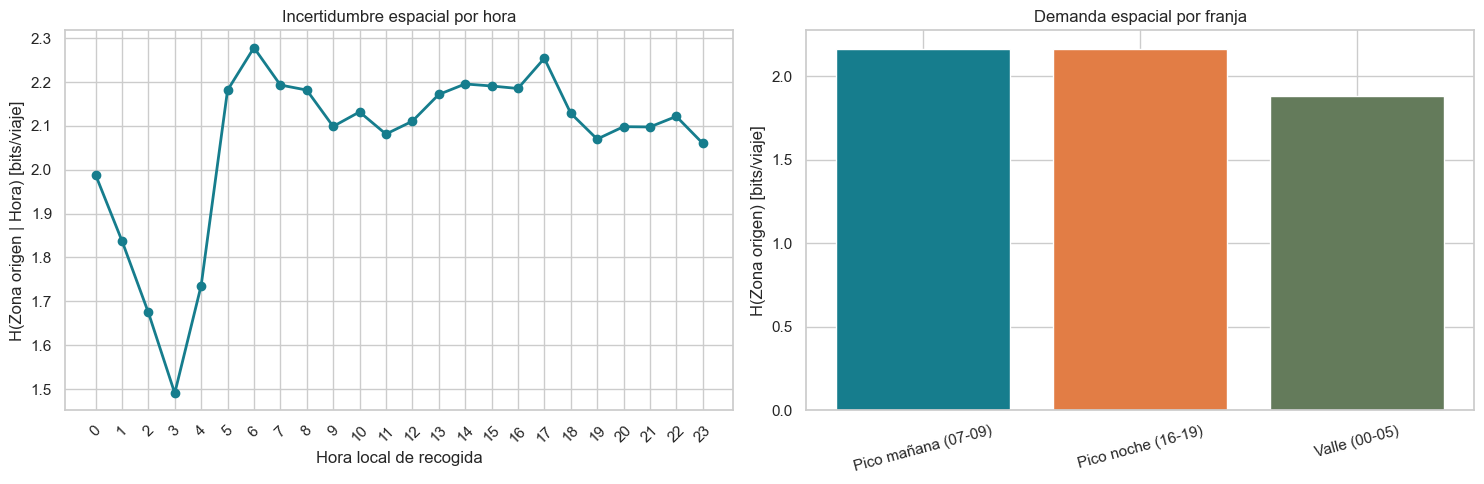

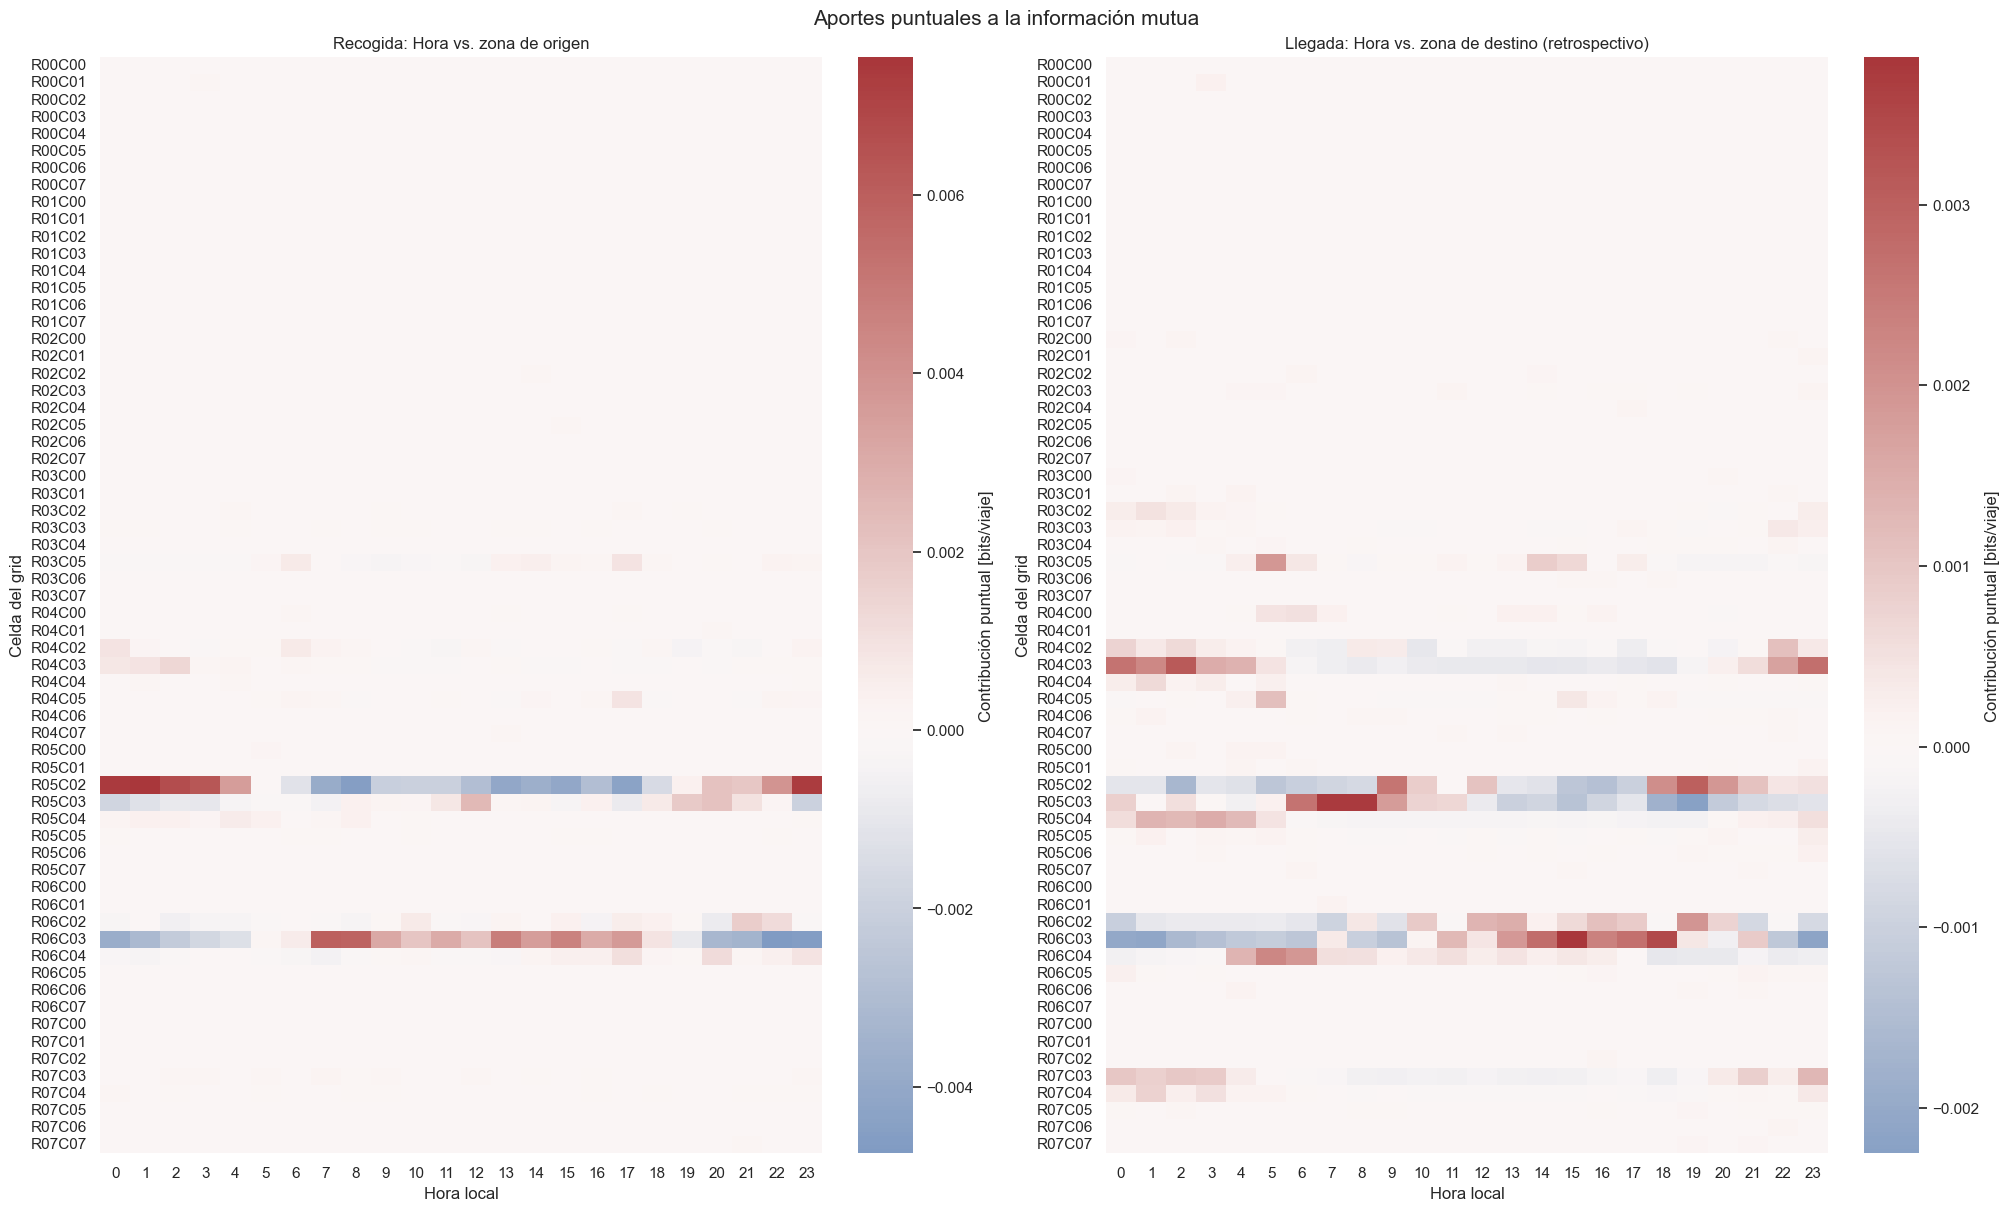

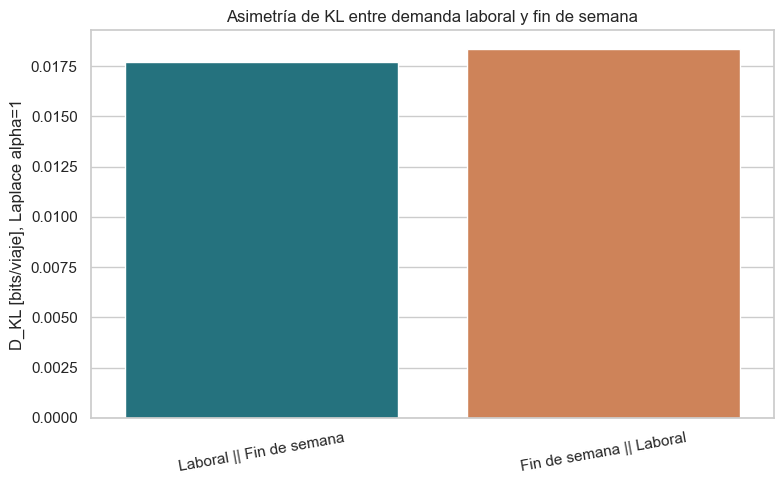

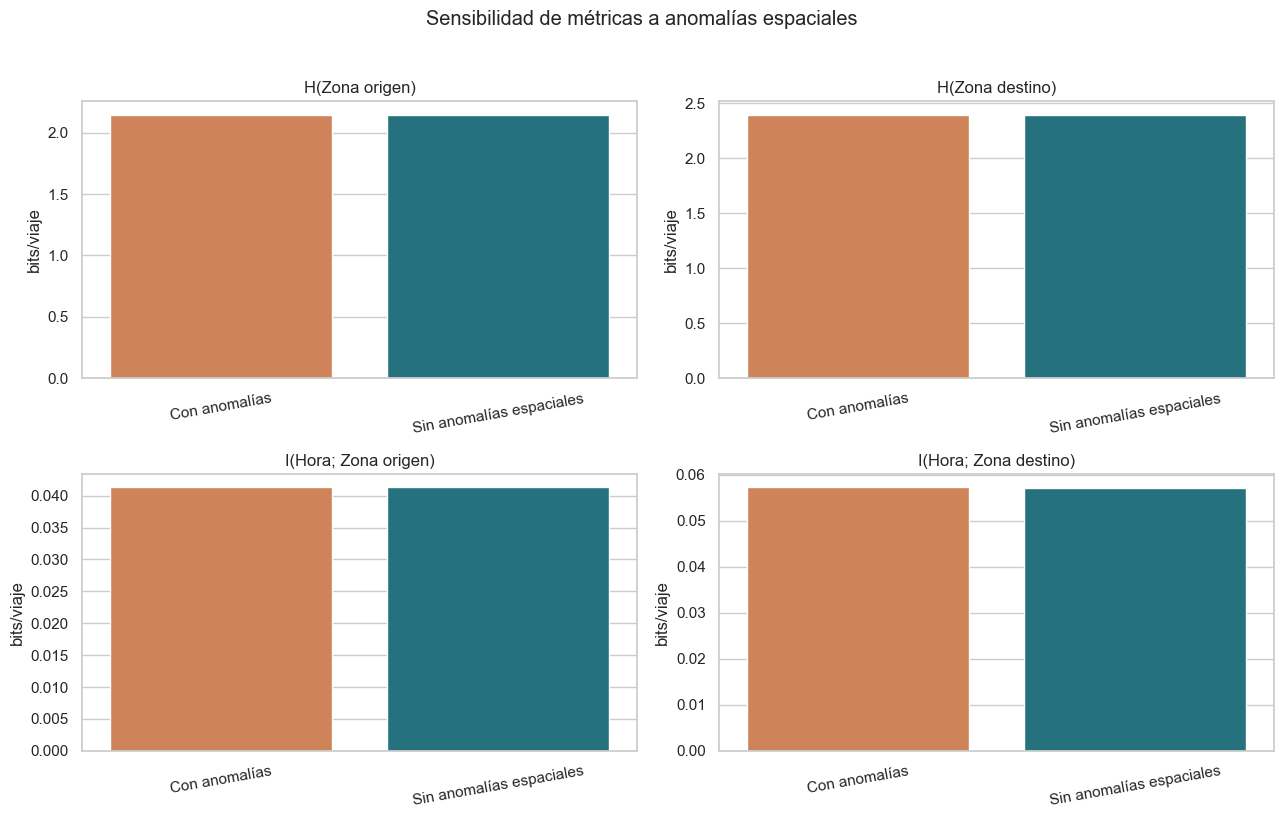

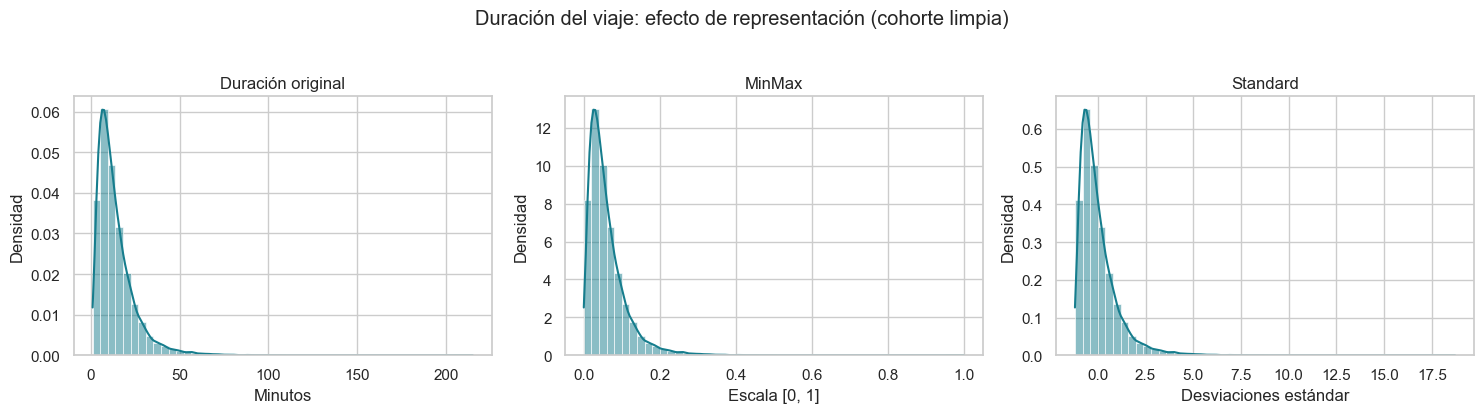

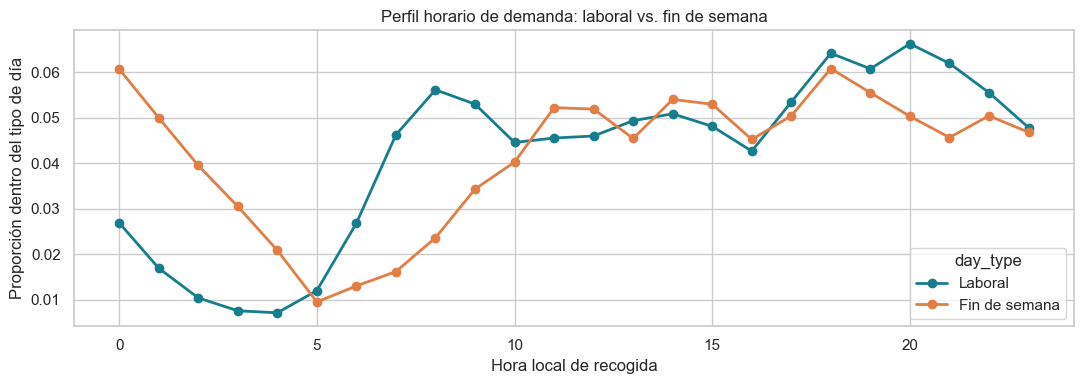

In [10]:
# Perfil de entropía espacial por hora y por franja de operación.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(HOURS, entropy_by_hour.to_numpy(), marker="o", linewidth=2, color="#167d8d")
axes[0].set(xticks=HOURS, xlabel="Hora local de recogida", ylabel="H(Zona origen | Hora) [bits/viaje]",
            title="Incertidumbre espacial por hora")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(list(H_by_band), list(H_by_band.values()), color=["#167d8d", "#e27d45", "#647b5b"])
axes[1].set_ylabel("H(Zona origen) [bits/viaje]")
axes[1].set_title("Demanda espacial por franja")
axes[1].tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "entropy_hourly_and_bands.png", dpi=180, bbox_inches="tight")
plt.show()

# Mapa hora-zona de contribución puntual a I(Hora; Zona), para origen y destino.
fig, axes = plt.subplots(1, 2, figsize=(20, 12), constrained_layout=True)
for axis, joint, title in [
    (axes[0], J_origin, "Recogida: Hora vs. zona de origen"),
    (axes[1], J_destination, "Llegada: Hora vs. zona de destino (retrospectivo)"),
]:
    contribution = pointwise_information_bits(joint).T
    sns.heatmap(contribution, ax=axis, cmap="vlag", center=0, xticklabels=HOURS,
                yticklabels=zone_support, cbar_kws={"label": "Contribución puntual [bits/viaje]"})
    axis.set_xlabel("Hora local")
    axis.set_ylabel("Celda del grid")
    axis.set_title(title)
fig.suptitle("Aportes puntuales a la información mutua", fontsize=15)
fig.savefig(FIGURES_DIR / "mutual_information_hour_zone.png", dpi=180, bbox_inches="tight")
plt.show()

# Comparación dirigida de KL; su asimetría importa al transferir una política entre tipos de día.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=kl_comparison, x="Dirección", y="Pérdida informativa", hue="Dirección", legend=False, ax=ax,
            palette=["#167d8d", "#e27d45"])
ax.set_ylabel("D_KL [bits/viaje], Laplace alpha=1")
ax.set_xlabel("")
ax.set_title("Asimetría de KL entre demanda laboral y fin de semana")
ax.tick_params(axis="x", rotation=10)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "kl_weekday_weekend.png", dpi=180, bbox_inches="tight")
plt.show()

# Contraste de entropía y asociación de origen/destino con y sin anomalías espaciales.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
noise_metrics = [
    ("H(Zona origen)", "bits/viaje"),
    ("H(Zona destino)", "bits/viaje"),
    ("I(Hora; Zona origen)", "bits/viaje"),
    ("I(Hora; Zona destino)", "bits/viaje"),
]
for axis, (metric, unit) in zip(axes.ravel(), noise_metrics):
    sns.barplot(data=noise_comparison, x="Cohorte", y=metric, hue="Cohorte", legend=False,
                palette=["#e27d45", "#167d8d"], ax=axis)
    axis.set_title(metric)
    axis.set_ylabel(unit)
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=10)
fig.suptitle("Sensibilidad de métricas a anomalías espaciales", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "noise_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

# Densidad de duración en minutos y después de dos transformaciones aprendidas en entrenamiento.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
density_series = [
    (raw_duration_sample, "Duración original", "Minutos"),
    (minmax_duration, "MinMax", "Escala [0, 1]"),
    (standard_duration, "Standard", "Desviaciones estándar"),
]
for axis, (values, title, xlabel) in zip(axes, density_series):
    sns.histplot(values, bins=50, stat="density", kde=True, color="#167d8d", ax=axis)
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel("Densidad")
fig.suptitle("Duración del viaje: efecto de representación (cohorte limpia)", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "duration_scaling.png", dpi=180, bbox_inches="tight")
plt.show()

# Perfil horario normalizado por tipo de día.
hour_day_counts = pd.crosstab(train_clean_features["hour"], train_clean_features["day_type"]).reindex(
    index=HOURS, columns=DAY_TYPES, fill_value=0
)
ax = hour_day_counts.div(hour_day_counts.sum(axis=0), axis=1).plot(
    figsize=(11, 4), marker="o", linewidth=2, color=["#167d8d", "#e27d45"]
)
ax.set(xlabel="Hora local de recogida", ylabel="Proporción dentro del tipo de día",
       title="Perfil horario de demanda: laboral vs. fin de semana")
fig = ax.figure
fig.tight_layout()
fig.savefig(FIGURES_DIR / "hourly_demand_by_day_type.png", dpi=180, bbox_inches="tight")
plt.show()

# **6. Resumen de Métricas y Recomendaciones Operativas UrbanMove**

La tabla reúne resultados del bloque de entrenamiento. Las recomendaciones se generan desde las métricas calculadas; los bits no se convierten a dólares ni a cantidad de vehículos sin costos, capacidad por conductor o tiempos de reposicionamiento, que este dataset no aporta.

In [11]:
def metric_record(name, value, unit, interpretation):
    return {"Métrica": name, "Valor": value, "Unidad": unit, "Lectura operativa": interpretation}


summary_rows = [
    metric_record("Viajes de entrenamiento con fecha válida", len(train_raw), "viajes", "Base temporal para métricas y comparación con/sin ruido"),
    metric_record("Viajes en perfil de recogida", len(train_clean_features), "viajes", "Recogidas válidas usadas para estimar demanda"),
    metric_record("Anomalías de cualquier tipo", 100 * train_raw["any_anomaly"].mean(), "% de entrenamiento", "Incluye extremos espaciales y temporales; no todos se excluyen de demanda"),
    metric_record("Recogidas fuera de NYC", 100 * train_raw["pickup_spatial_anomaly"].mean(), "% de entrenamiento", "Excluidas de las probabilidades operativas de recogida"),
    metric_record("Destinos fuera de NYC", 100 * train_raw["dropoff_spatial_anomaly"].mean(), "% de entrenamiento", "Excluidos solo de análisis retrospectivos de destino"),
    metric_record("Duración fuera de 1-360 min", 100 * train_raw["duration_anomaly"].mean(), "% de entrenamiento", "Diagnóstico de resultado; no filtra demanda ni priors"),
    metric_record("H(Zona origen)", entropy_bits(P_zone), "bits/viaje", "Incertidumbre espacial marginal"),
    metric_record("H(Zona | Hora)", H_zone_given_hour, "bits/viaje", "Incertidumbre espacial residual al conocer la hora"),
    metric_record("H(Demanda diaria | Tipo de día)", H_demand_given_day_type, "bits/día", "Incertidumbre del nivel diario tras conocer laboral/fin de semana"),
    metric_record("I(Hora; Zona origen)", MI_hour_origin, "bits/viaje", "Información temporal sobre zona de recogida"),
    metric_record("I(Hora; Zona destino)", MI_hour_destination, "bits/viaje", "Asociación retrospectiva; no está disponible al despacho"),
    metric_record("D_KL(Laboral || Fin de semana)", kl_bits(P_weekday, Q_weekend), "bits/viaje", "Diferencia dirigida de perfiles espaciales"),
    metric_record("D_KL(Fin de semana || Laboral)", kl_bits(Q_weekend, P_weekday), "bits/viaje", "Dirección inversa; no tiene por qué coincidir"),
    metric_record("H(Laboral, Fin de semana)", cross_entropy_bits(P_weekday, Q_weekend), "bits/viaje", "Costo informativo al codificar laboral con el perfil de fin de semana"),
    metric_record("H(Fin de semana, Laboral)", cross_entropy_bits(Q_weekend, P_weekday), "bits/viaje", "Costo informativo al codificar fin de semana con el perfil laboral"),
    metric_record("Jensen: E[log2 P(X)]", jensen_left, "bits", "Debe ser menor o igual que log2 E[P(X)]"),
    metric_record("Jensen: log2 E[P(X)]", jensen_right, "bits", "Cota superior comprobada numéricamente"),
    metric_record("Margen de Jensen", jensen_gap, "bits", "Diferencia no negativa entre ambos lados"),
    metric_record("h(duración original)", h_duration_raw, "nats; minutos", "Entropía diferencial dependiente de escala"),
    metric_record("h(duración MinMax)", h_duration_minmax, "nats; escala [0,1]", "Entropía diferencial después del escalado MinMax"),
    metric_record("h(duración Standard)", h_duration_standard, "nats; variable estandarizada", "Entropía diferencial después de StandardScaler"),
    metric_record("LSE([-1000,-1001,-999])", stable_underflow, "log-unidades", "Resultado finito frente al underflow ingenuo"),
    metric_record("LSE([1000,1001,999])", stable_overflow, "log-unidades", "Resultado finito frente al overflow ingenuo"),
]
summary_table = pd.DataFrame(summary_rows)
print("Resumen final (parámetros y perfiles ajustados únicamente en entrenamiento):")
display(summary_table.style.format({"Valor": "{:,.6f}"}))

# Recomendaciones calculadas directamente de las tablas de esta ejecución.
top_zone_count = max(1, int(np.ceil(0.10 * len(zone_support))))
top_zone_share = float(origin_counts.nlargest(top_zone_count).sum() / len(train_clean_features))
top_zone_names = ", ".join(origin_counts.nlargest(min(3, top_zone_count)).index.astype(str))
peak_hour = int(hour_counts.idxmax())
peak_hour_share = float(hour_counts.max() / len(train_clean_features))
peak_day_type_hours = {day_type: int(hour_day_counts[day_type].idxmax()) for day_type in DAY_TYPES}
highest_uncertainty_band = max(H_by_band, key=H_by_band.get)
lowest_uncertainty_band = min(H_by_band, key=H_by_band.get)
noise_row = noise_comparison.set_index("Cohorte")
noise_entropy_origin_delta = float(noise_row.loc["Con anomalías", "H(Zona origen)"] - noise_row.loc["Sin anomalías espaciales", "H(Zona origen)"])
noise_entropy_destination_delta = float(noise_row.loc["Con anomalías", "H(Zona destino)"] - noise_row.loc["Sin anomalías espaciales", "H(Zona destino)"])
noise_mi_origin_delta = float(noise_row.loc["Con anomalías", "I(Hora; Zona origen)"] - noise_row.loc["Sin anomalías espaciales", "I(Hora; Zona origen)"])
noise_mi_destination_delta = float(noise_row.loc["Con anomalías", "I(Hora; Zona destino)"] - noise_row.loc["Sin anomalías espaciales", "I(Hora; Zona destino)"])
pickup_anomaly_pct = 100 * train_raw["pickup_spatial_anomaly"].mean()
dropoff_anomaly_pct = 100 * train_raw["dropoff_spatial_anomaly"].mean()
duration_anomaly_pct = 100 * train_raw["duration_anomaly"].mean()
weekend_policy_penalty = kl_bits(Q_weekend, P_weekday)
weekend_cross_entropy = cross_entropy_bits(Q_weekend, P_weekday)
weekend_entropy = entropy_bits(Q_weekend)

recommendations = [
    (f"**Concentración espacial.** Las {top_zone_count} celdas principales (de 64) reúnen "
     f"{top_zone_share:.1%} de las recogidas limpias; entre las tres primeras están {top_zone_names}. "
     f"Considerarlas como candidatos de staging y contrastar esa cuota con la capacidad disponible antes de mover flota."),
    (f"**Cobertura horaria.** El mayor volumen ocurre a las {peak_hour:02d}:00 ({peak_hour_share:.1%} de los viajes); "
     f"el máximo por tipo de día es {peak_day_type_hours['Laboral']:02d}:00 en laborables y "
     f"{peak_day_type_hours['Fin de semana']:02d}:00 en fin de semana. Alinear disponibilidad y relevos con esos picos observados."),
    (f"**Incertidumbre de ubicación.** {highest_uncertainty_band} presenta {H_by_band[highest_uncertainty_band]:.3f} bits/viaje y "
     f"{lowest_uncertainty_band}, {H_by_band[lowest_uncertainty_band]:.3f} bits/viaje. Mantener mayor flexibilidad de posicionamiento "
     f"en la franja más incierta; comprobar el efecto con tiempos de espera, que este dataset no mide."),
    (f"**Planes por tipo de día.** Usar el perfil laboral en fin de semana tiene D_KL={weekend_policy_penalty:.4f} bits/viaje "
     f"y entropía cruzada {weekend_cross_entropy:.4f}, frente a H(fin de semana)={weekend_entropy:.4f} bits/viaje. "
     f"Mantener perfiles diferenciados si esa discrepancia informativa justifica operar dos planes; no equivale directamente a costo monetario."),
    (f"**Calidad y ruido.** El filtro de recogidas excluye {pickup_anomaly_pct:.3f}% de orígenes fuera de NYC; "
     f"{dropoff_anomaly_pct:.3f}% de destinos y {duration_anomaly_pct:.3f}% de duraciones fuera de rango se reportan por separado. "
     f"Con ruido, H(origen) cambia {noise_entropy_origin_delta:+.4f}, H(destino) {noise_entropy_destination_delta:+.4f}, "
     f"I(hora;origen) {noise_mi_origin_delta:+.4f} e I(hora;destino) {noise_mi_destination_delta:+.4f} bits/viaje. "
     f"Conservar estas validaciones antes de interpretar variaciones de mapa como cambios reales de demanda."),
    (f"**Dotación diaria.** H(Demanda | tipo de día)={H_demand_given_day_type:.4f} bits/día en tres niveles definidos "
     f"con terciles del entrenamiento; usar esta incertidumbre para evitar dotaciones rígidas sin contrastar más días."),
]
recommendation_markdown = "## Recomendaciones operativas basadas en esta ejecución\n\n" + "\n\n".join(
    f"{index}. {text}" for index, text in enumerate(recommendations, start=1)
)
display(Markdown(recommendation_markdown))

print("\nPuente técnico para ROL 3:")
print("Usar logsumexp_stable(log_values, axis=None) y log_mixture_probability(log_component_probabilities, weights, axis=0).")
print("Mantener los mismos log-pesos, escala logarítmica y soporte al integrar con GMM/EM.")

Resumen final (parámetros y perfiles ajustados únicamente en entrenamiento):


,Métrica,Valor,Unidad,Lectura operativa
0,Viajes de entrenamiento con fecha válida,"32,000.000000",viajes,Base temporal para métricas y comparación con/sin ruido
1,Viajes en perfil de recogida,"32,000.000000",viajes,Recogidas válidas usadas para estimar demanda
2,Anomalías de cualquier tipo,0.343750,% de entrenamiento,Incluye extremos espaciales y temporales; no todos se excluyen de demanda
3,Recogidas fuera de NYC,0.000000,% de entrenamiento,Excluidas de las probabilidades operativas de recogida
4,Destinos fuera de NYC,0.015625,% de entrenamiento,Excluidos solo de análisis retrospectivos de destino
5,Duración fuera de 1-360 min,0.328125,% de entrenamiento,Diagnóstico de resultado; no filtra demanda ni priors
6,H(Zona origen),2.146245,bits/viaje,Incertidumbre espacial marginal
7,H(Zona | Hora),2.104903,bits/viaje,Incertidumbre espacial residual al conocer la hora
8,H(Demanda diaria | Tipo de día),1.558425,bits/día,Incertidumbre del nivel diario tras conocer laboral/fin de semana
9,I(Hora; Zona origen),0.041342,bits/viaje,Información temporal sobre zona de recogida


## Recomendaciones operativas basadas en esta ejecución

1. **Concentración espacial.** Las 7 celdas principales (de 64) reúnen 98.5% de las recogidas limpias; entre las tres primeras están R05C02, R06C03, R05C03. Considerarlas como candidatos de staging y contrastar esa cuota con la capacidad disponible antes de mover flota.

2. **Cobertura horaria.** El mayor volumen ocurre a las 18:00 (6.3% de los viajes); el máximo por tipo de día es 20:00 en laborables y 18:00 en fin de semana. Alinear disponibilidad y relevos con esos picos observados.

3. **Incertidumbre de ubicación.** Pico mañana (07-09) presenta 2.165 bits/viaje y Valle (00-05), 1.880 bits/viaje. Mantener mayor flexibilidad de posicionamiento en la franja más incierta; comprobar el efecto con tiempos de espera, que este dataset no mide.

4. **Planes por tipo de día.** Usar el perfil laboral en fin de semana tiene D_KL=0.0184 bits/viaje y entropía cruzada 2.1689, frente a H(fin de semana)=2.1506 bits/viaje. Mantener perfiles diferenciados si esa discrepancia informativa justifica operar dos planes; no equivale directamente a costo monetario.

5. **Calidad y ruido.** El filtro de recogidas excluye 0.000% de orígenes fuera de NYC; 0.016% de destinos y 0.328% de duraciones fuera de rango se reportan por separado. Con ruido, H(origen) cambia +0.0000, H(destino) +0.0018, I(hora;origen) +0.0000 e I(hora;destino) +0.0003 bits/viaje. Conservar estas validaciones antes de interpretar variaciones de mapa como cambios reales de demanda.

6. **Dotación diaria.** H(Demanda | tipo de día)=1.5584 bits/día en tres niveles definidos con terciles del entrenamiento; usar esta incertidumbre para evitar dotaciones rígidas sin contrastar más días.


Puente técnico para ROL 3:
Usar logsumexp_stable(log_values, axis=None) y log_mixture_probability(log_component_probabilities, weights, axis=0).
Mantener los mismos log-pesos, escala logarítmica y soporte al integrar con GMM/EM.


## **6.1 Exportación de resultados a output/role_1**

Como en ROL 2, los resultados se persisten en una carpeta del rol. Cada ejecución actualiza los CSV y PNG para que los artefactos correspondan a los datos y parámetros actuales.

In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

output_tables = {
    "metricas_resumen.csv": summary_table,
    "probabilidades_zona_origen.csv": probability_tables["Zona de recogida"],
    "probabilidades_hora.csv": probability_tables["Hora de recogida"],
    "probabilidades_tipo_dia.csv": probability_tables["Tipo de día"],
    "comparacion_ruido.csv": noise_comparison,
    "comparacion_suavizado.csv": smoothing_comparison,
    "comparacion_escalado_continuo.csv": scaling_comparison,
    "comparacion_escalado_discreto.csv": discrete_scaling_comparison,
    "kl_direccional.csv": kl_comparison,
    "entropia_cruzada.csv": cross_entropy_comparison,
    "jensen.csv": jensen_result,
    "pruebas_logsumexp.csv": logsumexp_checks,
    "niveles_demanda_tipo_dia.csv": demand_by_day_type,
}
for filename, table in output_tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=True, encoding="utf-8")

recommendation_path = OUTPUT_DIR / "recomendaciones_operativas.md"
recommendation_path.write_text(recommendation_markdown + "\n", encoding="utf-8")

saved_files = [OUTPUT_DIR / filename for filename in output_tables]
saved_files.append(recommendation_path)
saved_files.extend(sorted(FIGURES_DIR.glob("*.png")))
print(f"Resultados CSV/Markdown guardados en: {OUTPUT_DIR}")
print(f"Figuras PNG guardadas en: {FIGURES_DIR}")
print(f"Artefactos generados: {len(saved_files)}")
for saved_file in saved_files:
    print(f" - {saved_file.relative_to(PROJECT_DIR)}")

Resultados CSV/Markdown guardados en: C:\Users\L0s3r\OneDrive\Documentos\GitHub\NYC-Taxi-Unsupervised-Learning\output\role_1
Figuras PNG guardadas en: C:\Users\L0s3r\OneDrive\Documentos\GitHub\NYC-Taxi-Unsupervised-Learning\output\role_1\figures
Artefactos generados: 20
 - output\role_1\metricas_resumen.csv
 - output\role_1\probabilidades_zona_origen.csv
 - output\role_1\probabilidades_hora.csv
 - output\role_1\probabilidades_tipo_dia.csv
 - output\role_1\comparacion_ruido.csv
 - output\role_1\comparacion_suavizado.csv
 - output\role_1\comparacion_escalado_continuo.csv
 - output\role_1\comparacion_escalado_discreto.csv
 - output\role_1\kl_direccional.csv
 - output\role_1\entropia_cruzada.csv
 - output\role_1\jensen.csv
 - output\role_1\pruebas_logsumexp.csv
 - output\role_1\niveles_demanda_tipo_dia.csv
 - output\role_1\recomendaciones_operativas.md
 - output\role_1\figures\duration_scaling.png
 - output\role_1\figures\entropy_hourly_and_bands.png
 - output\role_1\figures\hourly_demand_